In [1]:
import gpt as g
import sys, os
import numpy as np

from scipy.linalg import expm
import time
import matplotlib.pyplot as plt

SharedMemoryNone: SharedMemoryAllocate 1073741824 GPU implementation 
0SharedMemoryNone:  SharedMemoryNone.cc acceleratorAllocDevice 1073741824bytes at 0x300000000 for comms buffers 

__|__|__|__|__|__|__|__|__|__|__|__|__|__|__
__|__|__|__|__|__|__|__|__|__|__|__|__|__|__
__|_ |  |  |  |  |  |  |  |  |  |  |  | _|__
__|_                                    _|__
__|_   GGGG    RRRR    III    DDDD      _|__
__|_  G        R   R    I     D   D     _|__
__|_  G        R   R    I     D    D    _|__
__|_  G  GG    RRRR     I     D    D    _|__
__|_  G   G    R  R     I     D   D     _|__
__|_   GGGG    R   R   III    DDDD      _|__
__|_                                    _|__
__|__|__|__|__|__|__|__|__|__|__|__|__|__|__
__|__|__|__|__|__|__|__|__|__|__|__|__|__|__
  |  |  |  |  |  |  |  |  |  |  |  |  |  |  


Copyright (C) 2015 Peter Boyle, Azusa Yamaguchi, Guido Cossu, Antonin Portelli and other authors

This program is free software; you can redistribute it and/or modify
it under the term

In [2]:
size = 8
grid = g.grid([size, size, size, size], g.double)
rng = g.random("t")

U = g.qcd.gauge.unit(grid)
rng.normal_element(U)

GPT :       0.416937 s : Initializing gpt.random(t,vectorized_ranlux24_389_64) took 0.000108957 s


[lattice(ot_matrix_su_n_fundamental_group(3),double),
 lattice(ot_matrix_su_n_fundamental_group(3),double),
 lattice(ot_matrix_su_n_fundamental_group(3),double),
 lattice(ot_matrix_su_n_fundamental_group(3),double)]

In [21]:
# 1) compute flow Omega, check
# 2) apply left and right applications, check 
# 3) check ReTrU, check
#
#    completed naive implementation, need iterative/checkerboarded application
#
# 4) check invertability
# 5) calculate jacobian of single step
# 6) calculate determinant of Jacobian
# 7) calculate force from log det jacobian on one step
# 8) try propagating forces for a single left step.

In [22]:
#def div_A(U):
#    diff = U[0] - g.eval(g.adj(g.cshift(U[0], 0, -1)))
#    for mu in range(1, 4):
#        diff += (U[mu] - g.eval(g.adj(g.cshift(U[mu], mu, -1))))
#    divA = g.qcd.gauge.project.traceless_anti_hermitian(diff)
#    return divA

def div_A(U):
    a = g.qcd.gauge.fix.landau(U)
    V = g.mcolor(grid) # V is a SU(3) matrix on every lattice site
    rng.normal_element(V, scale=0.00)
    return a.gradient(V, 0.) * 1j

def exp_div_A(U, delta_t):
    a = g.matrix.exp(  - delta_t * div_A(U))
    V = g.mcolor(grid)
    a.otype = V.otype
    return a
    
def perform_gtf_at_site(U, delta_t, x):
    gtf = exp_div_A(U, delta_t)[x]
    for mu in range(4):
        U[mu][x] = g.group.compose(gtf, U[mu][x])
        y = x.copy()
        y[mu] = (y[mu] + size - 1)%size
        U[mu][y] = g.group.compose(U[mu][y], g.adj(gtf))


In [11]:
def gtf(U, delta_t):
    V = exp_div_A(U, delta_t)
    return g.qcd.gauge.transformed(U,V)

In [12]:
def trace_U(U):                                                      
    return sum(v for v in sum(u[:].real for u in g.eval(g.trace(U)))) / (4 * size**4 ) / 3.

In [13]:
a = g.qcd.gauge.fix.landau(U)
V = g.mcolor(grid) # V is a SU(3) matrix on every lattice site
rng.normal_element(V, scale=0.01)

#def iterative_gtf(U, delta_t):
    


lattice(ot_matrix_su_n_fundamental_group(3),double)

In [14]:
beta = g.default.get_float("--beta", 10.0)
seed = g.default.get("--seed", "hmc-pure-gauge")
ntherm = g.default.get_int("--ntherm", 10)
n = g.default.get_int("--n", 10)
nwrite = g.default.get_int("--nwrite", 10)
g.default.set_verbose("omf4")

#grid = g.grid([8, 8, 8, 8], g.double)
rng = g.random(seed)

U = g.qcd.gauge.unit(grid)
rng.normal_element(U)


GPT :      66.764721 s : Initializing gpt.random(hmc-pure-gauge,vectorized_ranlux24_389_64) took 0.000571012 s


[lattice(ot_matrix_su_n_fundamental_group(3),double),
 lattice(ot_matrix_su_n_fundamental_group(3),double),
 lattice(ot_matrix_su_n_fundamental_group(3),double),
 lattice(ot_matrix_su_n_fundamental_group(3),double)]

In [15]:


# conjugate momenta
mom = g.group.cartesian(U)

# Log
g.message(f"Lattice = {grid.fdimensions}")
g.message("Actions:")
# action for conj. momenta
a0 = g.qcd.scalar.action.mass_term()
g.message(f" - {a0.__name__}")

# wilson action
a1 = g.qcd.gauge.action.wilson(beta)
g.message(f" - {a1.__name__}")


def hamiltonian():
    return a0(mom) + a1(U)


# molecular dynamics
sympl = g.algorithms.integrator.symplectic

ip = sympl.update_p(mom, lambda: a1.gradient(U, U))
iq = sympl.update_q(U, lambda: a0.gradient(mom, mom))

# integrator
mdint = sympl.OMF4(25, ip, iq)
g.message(f"Integration scheme:\n{mdint}")

# metropolis
metro = g.algorithms.markov.metropolis(rng)

# MD units
tau = 2.0
g.message(f"tau = {tau} MD units")


def hmc(tau, mom):
    rng.normal_element(mom)
    accrej = metro(U)
    h0 = hamiltonian()
    mdint(tau)
    h1 = hamiltonian()
    return [accrej(h1, h0), h1 - h0]


# thermalization
for i in range(1, 11):
    h = []
    timer = g.timer("hmc")
    for _ in range(ntherm // 10):
        timer("trajectory")
        h += [hmc(tau, mom)]
    h = np.array(h)
    timer()
    g.message(f"{i*10} % of thermalization completed")
    g.message(timer)
    g.message(
        f"Plaquette = {g.qcd.gauge.plaquette(U)}, Acceptance = {np.mean(h[:,0]):.2f}, |dH| = {np.mean(np.abs(h[:,1])):.4e}"
    )

# production
history = []
for i in range(n):
    history += [hmc(tau, mom)]
    P = g.qcd.gauge.plaquette(U)
    g.message(f"Trajectory {i}, P={P}")
    
history = np.array(history)
g.message(f"Acceptance rate = {np.mean(history[:,0]):.2f}")
g.message(f"<|dH|> = {np.mean(np.abs(history[:,1])):.4e}")

GPT :      72.690068 s : Lattice = [8, 8, 8, 8]
GPT :      72.691453 s : Actions:
GPT :      72.692325 s :  - mass_term(m^-1 = 1.0)
GPT :      72.693147 s :  - wilson(10.0)
GPT :      72.696059 s : Integration scheme:
                       : OMF4(25, P, Q)
                       :   P(0.0033593261051506774, 0)
                       :   Q(0.01015914043364238, 0)
                       :   P(0.027289461342876364, 0)
                       :   Q(-0.0012921147061079868, 0)
                       :   P(-0.010648787448027042, 0)
                       :   Q(0.022265948544931215, 0)
                       :   P(-0.010648787448027042, 0)
                       :   Q(-0.0012921147061079868, 0)
                       :   P(0.027289461342876364, 0)
                       :   Q(0.01015914043364238, 0)
                       :   P(0.006718652210301355, 0)
                       :   Q(0.01015914043364238, 0)
                       :   P(0.027289461342876364, 0)
                       :   Q(-0.0012

GPT :  151236.928488 s : tau = 2.0 MD units
GPT :  151238.582625 s : 10 % of thermalization completed
GPT :  151238.582917 s : hmc:
                       : trajectory           1.65e+00 s (= 100.00 %); time/s = 1.65e+00/1.65e+00/1.65e+00 (min/max/avg)
GPT :  151238.583587 s : Plaquette = 0.3150660731904181, Acceptance = 1.00, |dH| = 2.2119e-02
GPT :  151240.203286 s : 20 % of thermalization completed
GPT :  151240.203580 s : hmc:
                       : trajectory           1.62e+00 s (= 100.00 %); time/s = 1.62e+00/1.62e+00/1.62e+00 (min/max/avg)
GPT :  151240.204214 s : Plaquette = 0.47711986081093766, Acceptance = 1.00, |dH| = 1.5962e-02
GPT :  151241.857490 s : 30 % of thermalization completed
GPT :  151241.857771 s : hmc:
                       : trajectory           1.65e+00 s (= 100.00 %); time/s = 1.65e+00/1.65e+00/1.65e+00 (min/max/avg)
GPT :  151241.858438 s : Plaquette = 0.595159830560408, Acceptance = 1.00, |dH| = 1.1691e-02
GPT :  151243.492079 s : 40 % of thermalization

In [16]:
V = g.copy(U)

plaq pre gtf =  0.782421850165409


<>:20: SyntaxWarning: invalid escape sequence '\m'
<>:20: SyntaxWarning: invalid escape sequence '\m'
/var/folders/d2/bw8ht0dn1pn7t1cyl1mlth7w0000gn/T/ipykernel_96727/681252306.py:20: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel("<ReTrU(x,$\mu$)>", size=20)


plaq post gtf =  0.7824218501654081


Text(0.5, 1.0, '8^4, PBC, $\\beta = 10.0$')

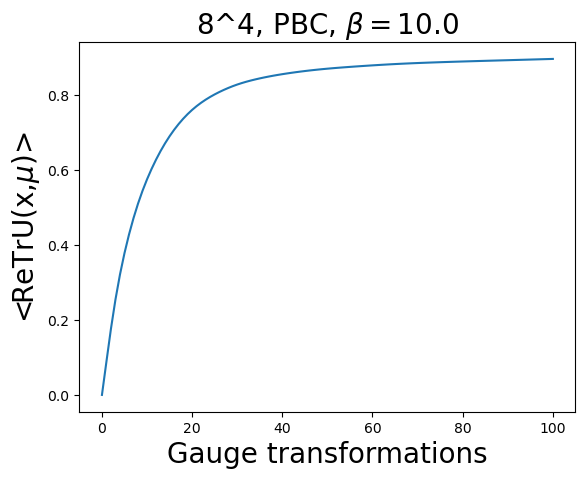

In [17]:
V = g.copy(U)
traces = []

traces.append(trace_U(V))
#print("trace = ", trace_U(U))
plaq = g.qcd.gauge.plaquette(V)
print("plaq pre gtf = ", plaq)

for i in range(100):
    V = gtf(V, 0.1)
    #print(trace_U(U))
    traces.append(trace_U(V))
    #plaq = g.qcd.gauge.plaquette(U)
    #print("plaq = ", plaq)
    
plaq = g.qcd.gauge.plaquette(V)
print("plaq post gtf = ", plaq)

plt.plot(traces)
plt.ylabel("<ReTrU(x,$\mu$)>", size=20)
plt.xlabel("Gauge transformations", size=20)
plt.title("8^4, PBC, $\\beta = 10.0$", size=20)

plaq pre gtf =  0.782421850165409


<>:20: SyntaxWarning: invalid escape sequence '\m'
<>:20: SyntaxWarning: invalid escape sequence '\m'
/var/folders/d2/bw8ht0dn1pn7t1cyl1mlth7w0000gn/T/ipykernel_96727/1122656307.py:20: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel("<ReTrU(x,$\mu$)>", size=20)


plaq post gtf =  0.7824218501654081


Text(0.5, 1.0, '8^4, PBC, $\\beta = 10.0$')

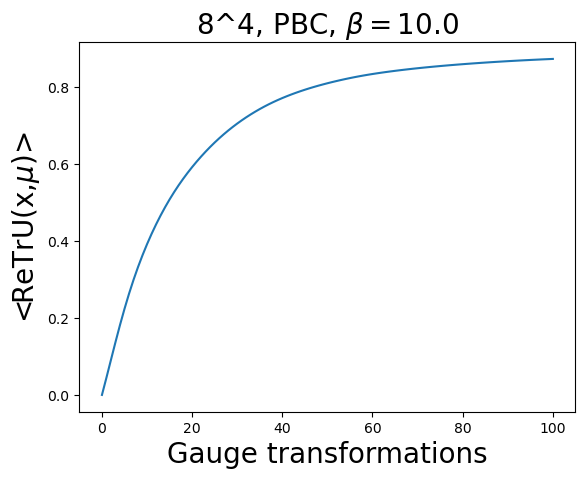

In [18]:
W = g.copy(U)

traces2 = []
traces2.append(trace_U(W))
#print("trace = ", trace_U(U))
plaq = g.qcd.gauge.plaquette(W)
print("plaq pre gtf = ", plaq)

for i in range(100):
    W = gtf(W, 0.05)
    #print(trace_U(U))
    traces2.append(trace_U(W))
    #plaq = g.qcd.gauge.plaquette(U)
    #print("plaq = ", plaq)
    
plaq = g.qcd.gauge.plaquette(W)
print("plaq post gtf = ", plaq)

plt.plot(traces2)
plt.ylabel("<ReTrU(x,$\mu$)>", size=20)
plt.xlabel("Gauge transformations", size=20)
plt.title("8^4, PBC, $\\beta = 10.0$", size=20)

In [85]:
traces2[-1]

array([0.87263957])

plaq pre gtf =  0.782421850165409
plaq post gtf =  0.7824218501654081


Text(0.5, 1.0, '8^4, PBC, $\\beta = 10.0$')

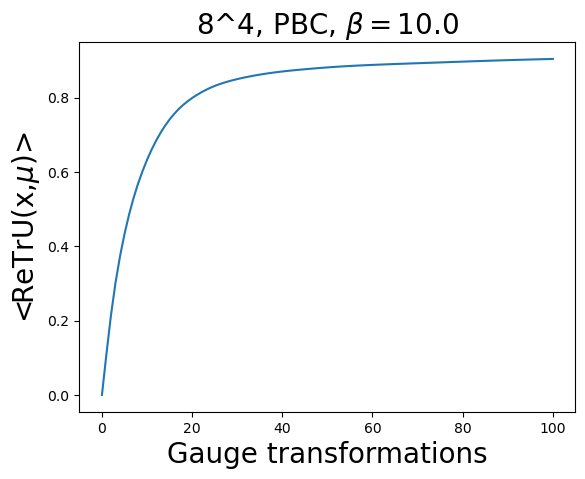

In [86]:
Z = g.copy(U)

traces3 = []
traces3.append(trace_U(Z))
#print("trace = ", trace_U(U))
plaq = g.qcd.gauge.plaquette(Z)
print("plaq pre gtf = ", plaq)

for i in range(100):
    Z = gtf(Z, 0.125)
    #print(trace_U(U))
    traces3.append(trace_U(Z))
    #plaq = g.qcd.gauge.plaquette(U)
    #print("plaq = ", plaq)
    
plaq = g.qcd.gauge.plaquette(Z)
print("plaq post gtf = ", plaq)

plt.plot(traces3)
plt.ylabel("<ReTrU(x,$\mu$)>", size=20)
plt.xlabel("Gauge transformations", size=20)
plt.title("8^4, PBC, $\\beta = 10.0$", size=20)

In [87]:
Z = g.copy(U)

traces4 = []
traces4.append(trace_U(Z))
#print("trace = ", trace_U(U))
plaq = g.qcd.gauge.plaquette(Z)
print("plaq pre gtf = ", plaq)

for i in range(100):
    Z = gtf(Z, 0.18)
    #print(trace_U(U))
    traces4.append(trace_U(Z))
    #plaq = g.qcd.gauge.plaquette(U)
    #print("plaq = ", plaq)
    
plaq = g.qcd.gauge.plaquette(Z)
print("plaq post gtf = ", plaq)


plaq pre gtf =  0.782421850165409
plaq post gtf =  0.7824218501654013


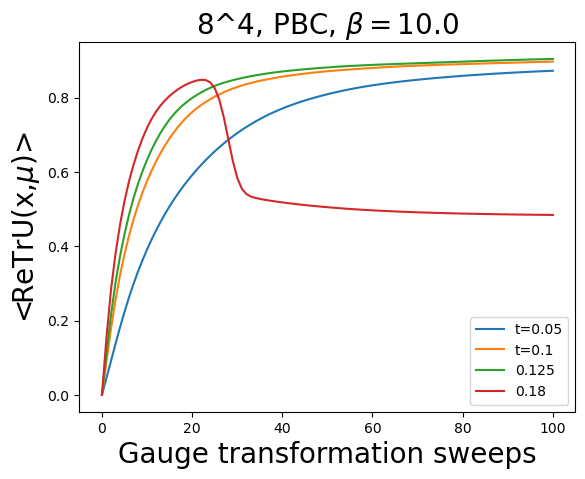

In [91]:
plt.plot(traces2, label='t=0.05')
plt.plot(traces, label='t=0.1')
plt.plot(traces3, label='0.125')
plt.plot(traces4, label='0.18')
plt.ylabel("<ReTrU(x,$\mu$)>", size=20)
plt.xlabel("Gauge transformation sweeps", size=20)
plt.title("8^4, PBC, $\\beta = 10.0$", size=20)
plt.legend()

$$
\Large U^g(x,\mu) = e^{-t \partial\cdot A(x)} U(x,\mu) e^{+t \partial\cdot A(x+\mu)} 
$$